# Oasis Infobyte Internship

## Data Analytics Internship

### Task 2: Customer Segmentation Analysis using K-Means Clustering

**Submitted by:** Yasashvi Agarwal

**Domain:** Data Analytics

**Organization:** Oasis Infobyte

**Tools Used:**
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn (K-Means Clustering)

**Dataset:** Mall Customers Dataset



## 1.Objective

The objective of this project is to perform customer segmentation using the K-Means Clustering algorithm. Customer segmentation helps businesses identify different groups of customers based on their annual income and spending behavior. This enables companies to create targeted marketing strategies and improve customer satisfaction.

## 2.Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

%matplotlib inline

## 3.Load the Dataset

In [14]:
!wget https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv

data = pd.read_csv("Mall_Customers.csv")

--2026-07-08 13:18:23--  https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4286 (4.2K) [text/plain]
Saving to: ‘Mall_Customers.csv.1’

Mall_Customers.csv. 100%[===================>]   4.19K  --.-KB/s    in 0s      

2026-07-08 13:18:23 (62.7 MB/s) - ‘Mall_Customers.csv.1’ saved [4286/4286]



## 4.Display First Five Rows

In [15]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Observation

The dataset contains customer information such as Customer ID, Gender, Age, Annual Income (k$), and Spending Score (1–100). These features will be used to analyze customer behavior and perform segmentation.

## 5.Dataset Information

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Observation

The dataset contains 200 customer records with 5 columns. There are no missing values, and the numerical features are stored in appropriate data types for analysis.

## 6. Dataset Shape

In [17]:
data.shape

(200, 5)

### Observation

The dataset consists of 200 rows and 5 columns, providing sufficient data for customer segmentation analysis.

## 7. Check Missing Values

In [18]:
data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Observation

The dataset does not contain any missing values. Therefore, no data cleaning is required before performing customer segmentation.

## 8. Statistical Summary

In [19]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Observation

The average customer age is around 39 years. The average annual income is approximately 60 thousand dollars, and the average spending score is about 50. The dataset contains customers with different age groups, income levels, and spending habits, making it suitable for customer segmentation.

## 9. Exploratory Data Analysis (EDA)

## 9.1 Gender Distribution

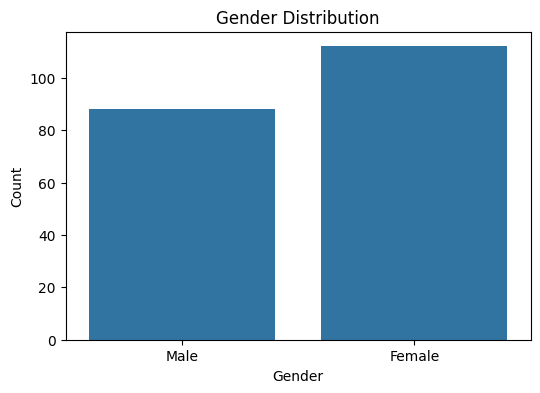

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Genre', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Observation
- Female customers are slightly more than male customers.
- The dataset has a balanced distribution of male and female customers.
- Both genders contribute significantly to the customer base.

### Business Insight
The company should create marketing strategies for both genders while introducing personalized offers to improve customer engagement and retention.

## 9.2 Age Distribution

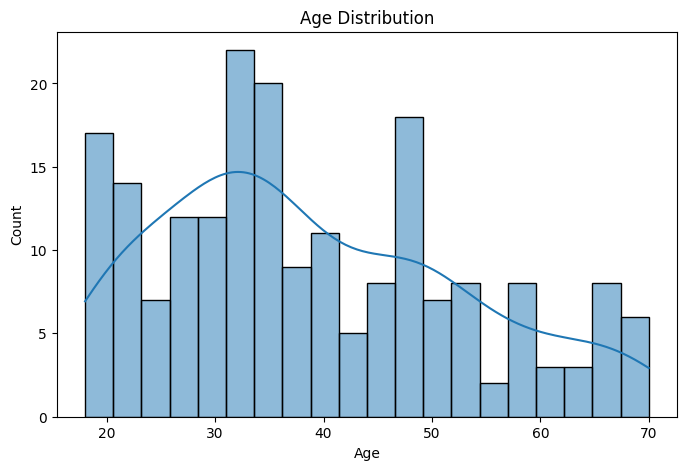

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Observation
- Most customers belong to the age group of 25–40 years.
- The number of customers decreases after the age of 50 years.
- Very few customers are above 60 years of age.

### Business Insight
The company should focus on products and marketing campaigns that appeal to young and middle-aged customers, as they represent the largest customer segment.

## 9.3 Annual Income Distribution

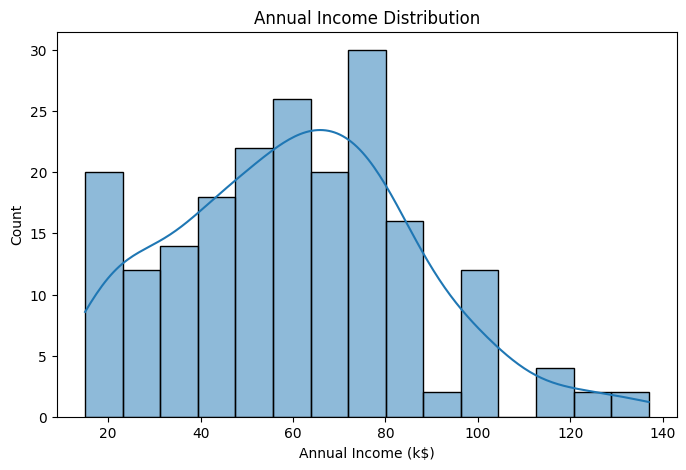

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data['Annual Income (k$)'], bins=15, kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')
plt.show()

### Observation
- Most customers have an annual income between 40k and 80k dollars.
- Only a few customers belong to the high-income category.
- Income is moderately distributed across different income ranges.

### Business Insight
The company should focus on offering value-for-money products for middle-income customers while introducing premium products and exclusive offers for high-income customers.

## 9.4 Spending Score Distribution

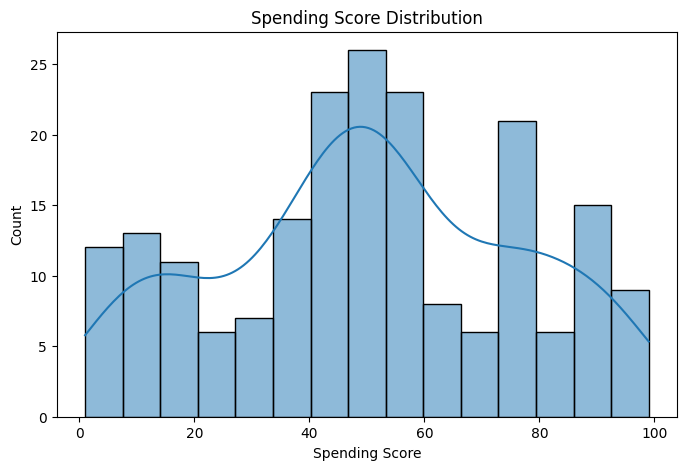

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data['Spending Score (1-100)'], bins=15, kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.show()

### Observation
- Most customers have spending scores between 40 and 60.
- Some customers have very high spending scores.
- Spending behavior varies across different customer groups.

### Business Insight
The company should reward high-spending customers with loyalty programs and personalized offers while encouraging low-spending customers through discounts and promotional campaigns.

## 10. Selecting Features

In [24]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Observation
- Annual Income and Spending Score are selected as the features for customer segmentation.
- These two features best represent customers' purchasing behavior and spending patterns.

### Business Insight
Using Annual Income and Spending Score helps businesses identify customer groups with similar purchasing habits, enabling more targeted marketing strategies.

## 11. Finding the Optimal Number of Clusters (Elbow Method)

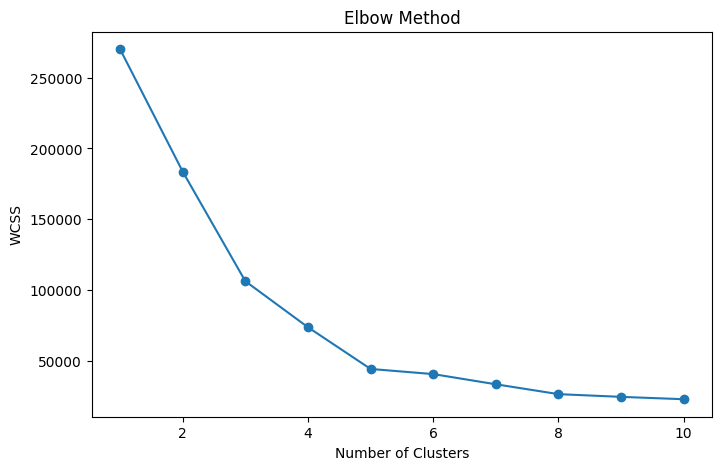

In [26]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### Observation
- The Elbow Method indicates that the optimal number of clusters is **5**.
- After 5 clusters, the decrease in WCSS becomes gradual.
- This suggests that dividing customers into 5 groups provides the best balance between accuracy and simplicity.

### Business Insight
Using 5 customer segments helps businesses better understand different customer behaviors and create personalized marketing strategies, improving customer satisfaction and sales.

## 12. Applying K-Means Clustering

In [27]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X)

data['Cluster'] = y_kmeans

## 13. Customer Segmentation using K-Means Clustering

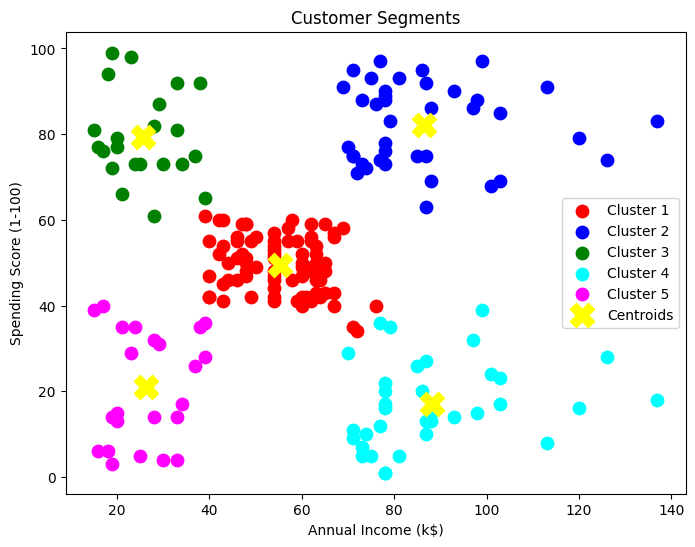

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(X.iloc[y_kmeans==0,0], X.iloc[y_kmeans==0,1],
            s=80, c='red', label='Cluster 1')

plt.scatter(X.iloc[y_kmeans==1,0], X.iloc[y_kmeans==1,1],
            s=80, c='blue', label='Cluster 2')

plt.scatter(X.iloc[y_kmeans==2,0], X.iloc[y_kmeans==2,1],
            s=80, c='green', label='Cluster 3')

plt.scatter(X.iloc[y_kmeans==3,0], X.iloc[y_kmeans==3,1],
            s=80, c='cyan', label='Cluster 4')

plt.scatter(X.iloc[y_kmeans==4,0], X.iloc[y_kmeans==4,1],
            s=80, c='magenta', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=300,
            c='yellow',
            marker='X',
            label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

### Observation
- Customers are successfully divided into **5 distinct clusters** based on Annual Income and Spending Score.
- Each cluster represents customers with similar purchasing behavior.
- The centroids indicate the average characteristics of each customer segment.
- High-income customers are divided into both high-spending and low

# 14. Conclusion

The Mall Customers dataset was successfully analyzed using Exploratory Data Analysis (EDA) and K-Means Clustering.

Key findings from the analysis include:

- Female customers are slightly more than male customers.
- Most customers belong to the age group of 25–40 years.
- The majority of customers have an annual income between 40k and 80k dollars.
- Most customers have spending scores between 40 and 60.
- The Elbow Method identified 5 as the optimal number of customer clusters.
- K-Means Clustering successfully segmented customers into five distinct groups based on Annual Income and Spending Score.

### Final Business Insight

Customer segmentation helps businesses understand different customer behaviors and preferences. These insights can be used to design targeted marketing campaigns, improve customer satisfaction, increase sales, and build long-term customer relationships.